
Líquido: Agua
Ajuste lineal: velocidad = 1.0000e-04 * presión + 3.4694e-18
Coeficiente de correlación (r): 1.0000
P-valor: 0.0000
Incidencia de incertidumbre en la velocidad: 0.0000e+00 m/s

Líquido: Aceite
Ajuste lineal: velocidad = 5.0000e-05 * presión + 1.7347e-18
Coeficiente de correlación (r): 1.0000
P-valor: 0.0000
Incidencia de incertidumbre en la velocidad: 0.0000e+00 m/s

Líquido: Glicerina
Ajuste lineal: velocidad = 1.0000e-05 * presión + 0.0000e+00
Coeficiente de correlación (r): 1.0000
P-valor: 0.0000
Incidencia de incertidumbre en la velocidad: 0.0000e+00 m/s


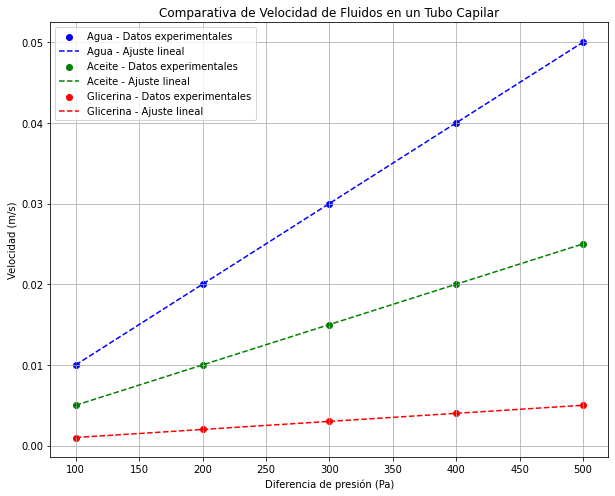

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Datos de los fluidos (viscosidad en Pa·s, y densidad en kg/m³)
fluido = {
    "Agua": {"viscosidad": 0.001, "densidad": 1000, "color": 'blue'},
    "Aceite": {"viscosidad": 0.05, "densidad": 920, "color": 'green'},
    "Glicerina": {"viscosidad": 1.5, "densidad": 1260, "color": 'red'}
}

# Parámetros del tubo
radio_tubo = 0.005  # Radio del tubo en metros
longitud_tubo = 0.5  # Longitud del tubo en metros

# Diferencias de presión (Pa)
presiones = np.array([100, 200, 300, 400, 500])  # Diferencia de presión en Pa

# Datos de mediciones para cada fluido (simulando velocidad en m/s)
datos_experimentales = {
    "Agua": {"presion": presiones, "velocidad": np.array([0.01, 0.02, 0.03, 0.04, 0.05])},
    "Aceite": {"presion": presiones, "velocidad": np.array([0.005, 0.01, 0.015, 0.02, 0.025])},
    "Glicerina": {"presion": presiones, "velocidad": np.array([0.001, 0.002, 0.003, 0.004, 0.005])}
}

# Gráfica y cálculo de la velocidad para cada fluido
plt.figure(figsize=(10, 8))

for liquido, params in fluido.items():
    # Obtener presión y velocidad
    presion = datos_experimentales[liquido]["presion"]
    velocidad = datos_experimentales[liquido]["velocidad"]
    
    # Calcular la velocidad esperada utilizando la ecuación de Poiseuille
    velocidad_teorica = (presion * radio_tubo**2) / (4 * params["viscosidad"] * longitud_tubo)
    
    # Ajuste lineal
    pendiente, intercepto, r_value, p_value, std_err = stats.linregress(presion, velocidad)

    # Graficar los datos experimentales y el ajuste lineal
    plt.scatter(presion, velocidad, color=params["color"], label=f'{liquido} - Datos experimentales')
    plt.plot(presion, pendiente * presion + intercepto, color=params["color"], linestyle='--', label=f'{liquido} - Ajuste lineal')

    # Imprimir los resultados del ajuste
    print(f"\nLíquido: {liquido}")
    print(f"Ajuste lineal: velocidad = {pendiente:.4e} * presión + {intercepto:.4e}")
    print(f"Coeficiente de correlación (r): {r_value:.4f}")
    print(f"P-valor: {p_value:.4f}")
    print(f"Incidencia de incertidumbre en la velocidad: {std_err:.4e} m/s")

# Personalizar la gráfica
plt.xlabel('Diferencia de presión (Pa)')
plt.ylabel('Velocidad (m/s)')
plt.title('Comparativa de Velocidad de Fluidos en un Tubo Capilar')
plt.legend()
plt.grid(True)
plt.show()

